In [1]:
rm(list=ls())
# Librerías ====
if(!require('pacman')) install.packages('pacman')
pacman::p_load(tidyverse,srvyr,showtext)
font_add_google("Poppins", "pop")
showtext_auto()

Cargando paquete requerido: pacman



In [2]:
urls<- list(
  Banobras = "https://transparencia.gob.mx/basesdatos/pensiones_BANOBRAS.xlsx",
  Bancomext = "https://transparencia.gob.mx/basesdatos/pensiones_BANCOMEXT.xlsx",
  Banrural = "https://transparencia.gob.mx/basesdatos/pensiones_BANRURAL.xlsx",
  CFE = "https://transparencia.gob.mx/basesdatos/pensiones_CFE.xlsx",
  LyFC = "https://transparencia.gob.mx/basesdatos/pensiones_LyFC.xlsx",
  NAFIN = "https://transparencia.gob.mx/basesdatos/pensiones_NAFIN.xlsx",
  PEMEX = "https://transparencia.gob.mx/basesdatos/pensiones_PEMEX.xlsx"


)

In [3]:
#Nombres de las columnas
columnas <- c(
  "no",
  "ejercicio",
  "nombre",
  "apellido_paterno",
  "apellido_materno",
  "institucion",
  "estatus",
  "sexo",
  "monto",
  "periodicidad"
)
#Consolidar información
pensiones <- map_df(names(urls), function(nombre){

  url <- urls[[nombre]]

  df <- openxlsx::read.xlsx(url, startRow = 3)

  names(df) <- columnas[1:ncol(df)]

  df$institucion_fuente <- nombre

  df
})
print(paste0("Total de registros ", nrow(pensiones)))
head(pensiones, 10)

[1] "Total de registros 99557"


,no,ejercicio,nombre,apellido_paterno,apellido_materno,institucion,estatus,sexo,monto,periodicidad,institucion_fuente
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,2025,JORGE,ABAD,RAMIREZ,BANOBRAS,Jubilado (a),Hombre,48919.35,Mensual,Banobras
2,2,2025,ADRIAN,ABARCA,GARCIA,BANOBRAS,Jubilado (a),Hombre,84969.19,Mensual,Banobras
3,3,2025,ANTONIO,ABREU,MUÑOZ,BANOBRAS,Jubilado (a),Hombre,59968.33,Mensual,Banobras
4,4,2025,JUANA SOLEDAD,ACEVEDO,GARCIA,BANOBRAS,Jubilado (a),Mujer,31276.51,Mensual,Banobras
5,5,2025,TOMAS JAIME,ACEVES,LARA,BANOBRAS,Jubilado (a),Hombre,83159.38,Mensual,Banobras
6,6,2025,MARIA DE JESUS,ACEVES,RUIZ,BANOBRAS,Jubilado (a),Mujer,66138.69,Mensual,Banobras
7,7,2025,MARIA PATRICIA,ACOSTA,RODRIGUEZ,BANOBRAS,Jubilado (a),Mujer,41681.92,Mensual,Banobras
8,8,2025,GRACIELA DEL CARMEN,ACOSTA,MENDEZ,BANOBRAS,Jubilado (a),Mujer,36484.21,Mensual,Banobras
9,9,2025,LUIS MANUEL,ACUÑA,GUERRERO,BANOBRAS,Jubilado (a),Hombre,80784.34,Mensual,Banobras


In [4]:
##Obtener máximos, minimos, media y mediana
print(unique(pensiones$periodicidad))
summary(pensiones$monto[pensiones$monto > 0])

[1] "Mensual"  "Mensual "


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
      0.9   45050.6   61498.3   71526.3   87198.6 1107361.3 

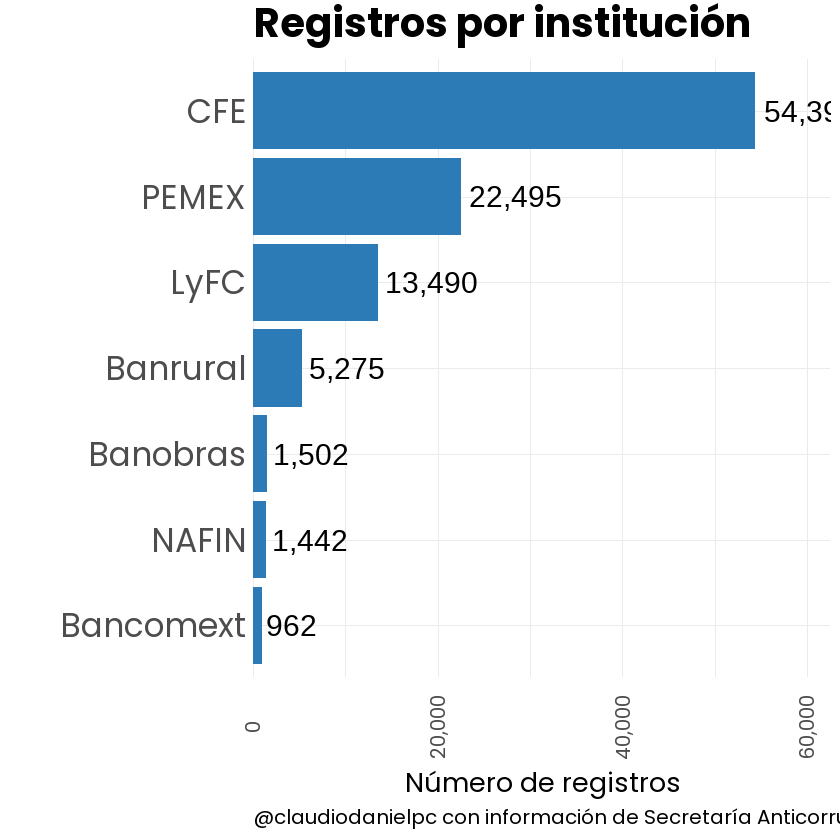

In [5]:
# Registros por institución

pensiones %>%
  count(institucion_fuente, name = "registros") %>%
  arrange(registros) %>%
  mutate(institucion_fuente = factor(institucion_fuente, levels = institucion_fuente)) %>%
  ggplot(aes(x = registros, y = institucion_fuente)) +
  geom_col(fill = "#2c7bb6") +
  geom_text(aes(label = scales::comma(registros)), hjust = -0.1, size = 8) +
  scale_x_continuous(labels = scales::comma, expand = expansion(mult = c(0, 0.15))) +
  labs(
    title = "Registros por institución",
    x = "Número de registros",
    y = NULL,
            caption= "@claudiodanielpc con información de Secretaría Anticorrupción y Buen Gobierno.",

  ) + theme_minimal()+  theme(
            plot.title = element_text(hjust = 0, size=30,face="bold"),
            plot.subtitle = element_text(hjust = 0, size=20, face="italic"),
            plot.caption = element_text(hjust = 0,size=15),
            axis.text.x = element_text(angle = 90, vjust = 0.5,size=15),
            axis.text.y = element_text(size=25),
            text=element_text("pop",size=20))

ggsave("pensiones_institucion.png", height=10, width=10, units='in', dpi=100,bg="white")


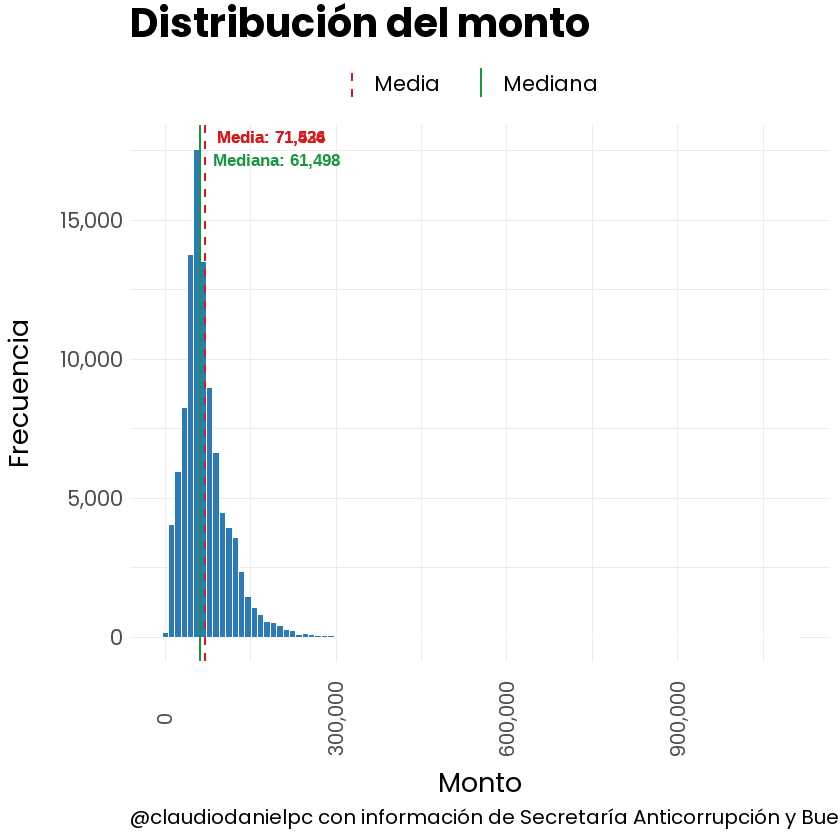

In [6]:
pensiones %>%
filter(monto>0)%>%
  ggplot(aes(x = monto)) +
  geom_histogram(fill = "#2c7bb6", color = "white", bins = 100) +
  geom_vline(aes(xintercept = mean(monto, na.rm = TRUE), color = "Media"),
             linewidth = 0.8, linetype = "dashed") +
  geom_vline(aes(xintercept = median(monto, na.rm = TRUE), color = "Mediana"),
             linewidth = 0.8, linetype = "solid") +
             annotate("text",
         x = mean(pensiones$monto, na.rm = TRUE),
         y = Inf,
         label = paste0("Media: ", scales::comma(round(mean(pensiones$monto, na.rm = TRUE), 0))),
         color = "#d7191c", hjust = -0.1, vjust = 1.5, size = 4.5, fontface = "bold") +
annotate("text",
         x = mean(pensiones$monto[pensiones$monto > 0], na.rm = TRUE),
         y = Inf,
         label = paste0("Media: ", scales::comma(round(mean(pensiones$monto[pensiones$monto > 0], na.rm = TRUE), 0))),
         color = "#d7191c", hjust = -0.1, vjust = 1.5, size = 4.5, fontface = "bold") +
annotate("text",
         x = median(pensiones$monto[pensiones$monto > 0], na.rm = TRUE),
         y = Inf,
         label = paste0("Mediana: ", scales::comma(round(median(pensiones$monto[pensiones$monto > 0], na.rm = TRUE), 0))),
         color = "#1a9641", hjust = -0.1, vjust = 3.5, size = 4.5, fontface = "bold") +

  scale_color_manual(values = c("Media" = "#d7191c", "Mediana" = "#1a9641")) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribución del monto",
            caption= "@claudiodanielpc con información de Secretaría Anticorrupción y Buen Gobierno.",

    x = "Monto",
    y = "Frecuencia",
    color = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "top") +   theme(
            plot.title = element_text(hjust = 0, size=30,face="bold"),
            plot.subtitle = element_text(hjust = 0, size=20, face="italic"),
            plot.caption = element_text(hjust = 0,size=15),
            axis.text.x = element_text(angle = 90, vjust = 0.5,size=15),
            text=element_text("pop",size=20))


ggsave("hist_montos_pensiones_tot.png", height=10, width=10, units='in', dpi=100,bg="white")


Warning message:
"Removed 995 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 995 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


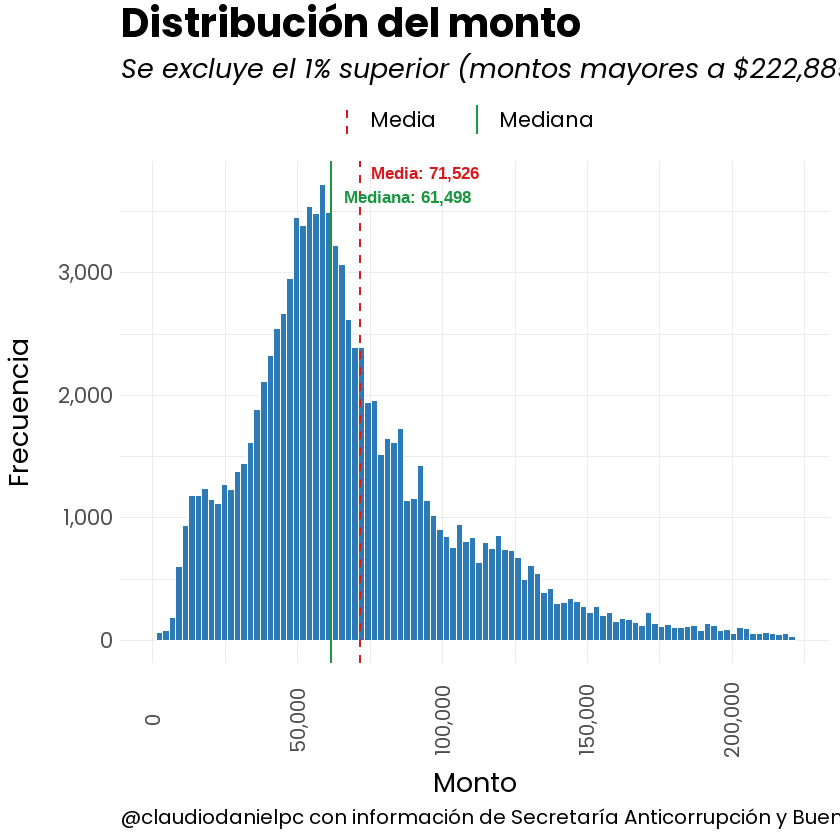

In [7]:
p99 <- quantile(pensiones$monto[pensiones$monto > 0], 0.99, na.rm = TRUE)
pensiones %>%
filter(monto>0)%>%
  ggplot(aes(x = monto)) +
  geom_histogram(fill = "#2c7bb6", color = "white", bins = 100) +
  geom_vline(aes(xintercept = mean(monto, na.rm = TRUE), color = "Media"),
             linewidth = 0.8, linetype = "dashed") +
  geom_vline(aes(xintercept = median(monto, na.rm = TRUE), color = "Mediana"),
             linewidth = 0.8, linetype = "solid") +
 annotate("text",
         x = mean(pensiones$monto[pensiones$monto > 0], na.rm = TRUE),
         y = Inf,
         label = paste0("Media: ", scales::comma(round(mean(pensiones$monto[pensiones$monto > 0], na.rm = TRUE), 0))),
         color = "#d7191c", hjust = -0.1, vjust = 1.5, size = 4.5, fontface = "bold") +
annotate("text",
         x = median(pensiones$monto[pensiones$monto > 0], na.rm = TRUE),
         y = Inf,
         label = paste0("Mediana: ", scales::comma(round(median(pensiones$monto[pensiones$monto > 0], na.rm = TRUE), 0))),
         color = "#1a9641", hjust = -0.1, vjust = 3.5, size = 4.5, fontface = "bold") +
  scale_color_manual(values = c("Media" = "#d7191c", "Mediana" = "#1a9641")) +
  scale_x_continuous(labels = scales::comma,
                     limits = c(0, p99)) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribución del monto",

    subtitle = paste0("Se excluye el 1% superior (montos mayores a $", scales::comma(round(p99, 0)), ")"),
        caption= "@claudiodanielpc con información de Secretaría Anticorrupción y Buen Gobierno.",

    x = "Monto",
    y = "Frecuencia",
    color = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "top",
        plot.title = element_text(hjust = 0, size = 30, face = "bold"),
        plot.subtitle = element_text(hjust = 0, size = 20, face = "italic"),
        plot.caption = element_text(hjust = 0, size = 15),
        axis.text.x = element_text(angle = 90, vjust = 0.5, size = 15),
        text = element_text("pop", size = 20))

ggsave("hist_montos_pensiones_limpio.png", height=10, width=10, units='in', dpi=100,bg="white")



#### Cargar ENIGH para calcular ingreso

In [8]:
#Crear directorio para guardar los archivos
dir.create("data", showWarnings = FALSE)

#limpiar el directorio
file.remove(list.files("data/", full.names = TRUE))

Warning message in file.remove(list.files("data/", full.names = TRUE)):
"no fue posible abrir el archivo 'data/inpc', motivo 'Permission denied'"


[1]  TRUE  TRUE FALSE

In [9]:
url_basica<-"https://www.inegi.org.mx/contenidos/programas/enigh/nc/"
segunda_parte<-"microdatos/enigh"
fin<-"_ns_concentradohogar_csv.zip"

In [10]:
years<-c("2024")
years

[1] "2024"

In [11]:
# Descargar los archivos, descomprimirlos y renombrarlos
options(timeout = 300) 
for (i in 1:length(years)) {
  url <- paste0(url_basica, years[i], "/", segunda_parte, years[i], fin)
  destfile <- paste0("data/", years[i], fin)

  # Descargar el archivo
  download.file(url, destfile = destfile)

  # Descomprimir el archivo
  unzip(destfile, exdir = "data")

  # Renombrar el archivo descomprimido a "viviendas_xxxx.csv"
  file.rename(
    from = "data/concentradohogar.csv",
    to = paste0("data/concentradohogar_", years[i], ".csv")
  )
}

In [12]:
url_inpc<-"https://www.inegi.org.mx/contenidos/programas/inpc/2018a/datosabiertos/conjunto_de_datos_inpc_indicador_mensual_csv.zip"
unlink("data/inpc/inpc.zip", recursive = TRUE)
download.file(url_inpc, destfile = "data/inpc/inpc.zip")
#Descomprimir el archivo
unzip("data/inpc/inpc.zip", exdir = "data/inpc")

In [13]:
#Leer INPC
inpc <- read_csv("data/inpc/conjunto_de_datos/conjunto_de_datos_inpc_mensual.csv",show_col_types = FALSE) %>%
  janitor::clean_names()%>%
  #Extraer year y month
  mutate(year=substr(fecha,1,4),
         month=substr(fecha,6,7))%>%
         filter(concepto=="Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Precios al Consumidor (INPC)")%>%
         select(year,month,valor)%>%
         filter(year>=2024 & year<=2025)%>%
         #Obtener el promedio anual
group_by(year)%>%
summarise(valor=mean(valor))%>%
#Cambiar la base a 2025=100
mutate(inpcbase=valor/valor[year=="2025"]*100)%>%
mutate(year=as.integer(year))

inpc

year,valor,inpcbase
<int>,<dbl>,<dbl>
2024,135.3846,96.33022
2025,140.5422,100.00000


In [14]:
path <- list.files("data",
                    pattern = "^concentradohogar_\\d{4}\\.csv$",
                    full.names = TRUE)
path

[1] "data/concentradohogar_2024.csv"

In [15]:
#Leer enigh 2024
enigh24<- read_csv(path, show_col_types = FALSE) %>%
  mutate(ing_mensual = ing_cor,
  educacion_mensual = educacion
  )%>%
  #Calcular ingreso mensual
  mutate(ing_mensual=ing_cor/3)

In [16]:
  #Diseño muestral
  mydesign <- enigh24 %>%
    as_survey_design(ids = upm, strata = est_dis, weights = factor)

In [17]:
#Obtener el ingreso promedio mensual del hogar y llevarlo a precios de 2025
ingreso<-mydesign%>%
summarise(ing_prom = survey_mean(ing_mensual, vartype = "cv"))%>%
#Crear variable year
mutate(year=2024)   %>% left_join(inpc)%>%
    mutate(ing_prom_real=ing_prom/inpcbase*100)

ingreso

Joining with `by = join_by(year)`


ing_prom,ing_prom_cv,year,valor,inpcbase,ing_prom_real
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25954.61,0.007777986,2024,135.3846,96.33022,26943.38


In [18]:
##Integrantes promedio de un hogar en México
mydesign%>%
summarise(integrantes = survey_mean(tot_integ, vartype = "cv"))

integrantes,integrantes_cv
<dbl>,<dbl>
3.353733,0.002991338


In [19]:
#Pegar ing_prom_real a pensiones

pensiones_ing<-pensiones%>%
filter(monto>0)%>%
mutate(ing_prom_real = ingreso$ing_prom_real,
#Calcular veces que monto representa de ing_prom_real
veces_ing=monto/ing_prom_real)
head(pensiones_ing,5)

,no,ejercicio,nombre,apellido_paterno,apellido_materno,institucion,estatus,sexo,monto,periodicidad,institucion_fuente,ing_prom_real,veces_ing
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,1,2025,JORGE,ABAD,RAMIREZ,BANOBRAS,Jubilado (a),Hombre,48919.35,Mensual,Banobras,26943.38,1.815636
2,2,2025,ADRIAN,ABARCA,GARCIA,BANOBRAS,Jubilado (a),Hombre,84969.19,Mensual,Banobras,26943.38,3.153621
3,3,2025,ANTONIO,ABREU,MUÑOZ,BANOBRAS,Jubilado (a),Hombre,59968.33,Mensual,Banobras,26943.38,2.225717
4,4,2025,JUANA SOLEDAD,ACEVEDO,GARCIA,BANOBRAS,Jubilado (a),Mujer,31276.51,Mensual,Banobras,26943.38,1.160824
5,5,2025,TOMAS JAIME,ACEVES,LARA,BANOBRAS,Jubilado (a),Hombre,83159.38,Mensual,Banobras,26943.38,3.086450


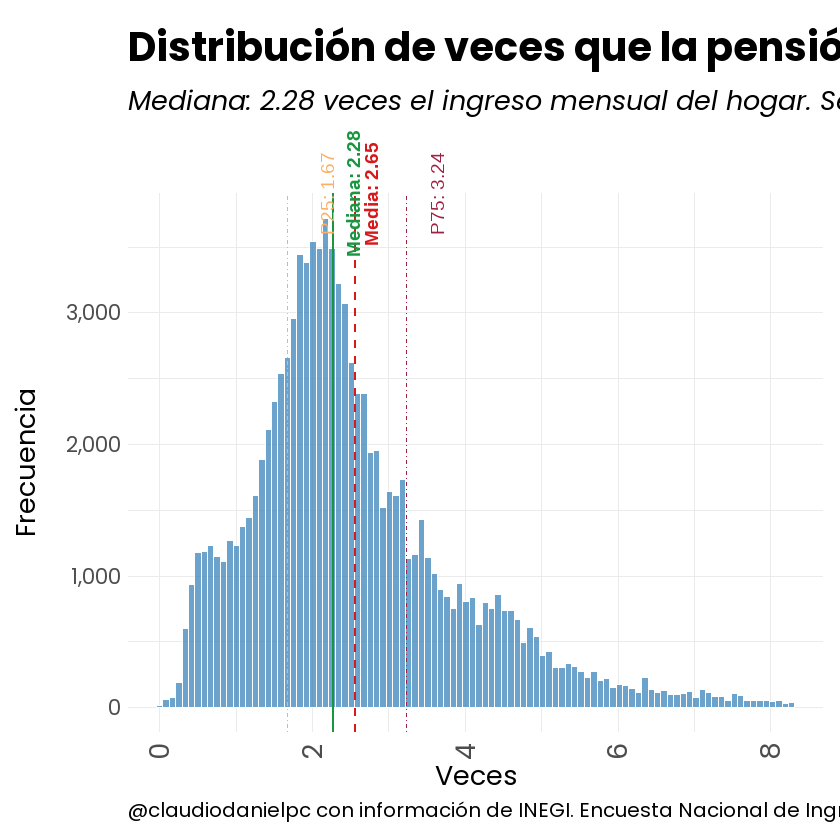

In [20]:
p99 <- quantile(pensiones_ing$veces_ing, 0.99, na.rm = TRUE)
p25 <- quantile(pensiones_ing$veces_ing, 0.25, na.rm = TRUE)
p75 <- quantile(pensiones_ing$veces_ing, 0.75, na.rm = TRUE)
p90 <- quantile(pensiones_ing$veces_ing, 0.90, na.rm = TRUE)
media <- mean(pensiones_ing$veces_ing, na.rm = TRUE)
mediana <- median(pensiones_ing$veces_ing, na.rm = TRUE)

pensiones_ing %>%
filter(veces_ing <= p99)%>%
  ggplot(aes(x = veces_ing)) +
  geom_histogram(fill = "#2c7bb6", color = "white", bins = 100, alpha = 0.7) +
  geom_vline(aes(xintercept = mean(veces_ing, na.rm = TRUE), color = "Media"),
             linewidth = 0.8, linetype = "dashed") +
  geom_vline(aes(xintercept = median(veces_ing, na.rm = TRUE), color = "Mediana"),
             linewidth = 0.8, linetype = "solid") +
geom_vline(xintercept = p25, color = "#fdae61", linetype = "dotdash") +
geom_vline(xintercept = p75, color = "#9F2241", linetype = "dotdash") +
annotate("text",
         x = media,
         y = Inf,
         label = paste0("Media: ", scales::number(media, accuracy = 0.01)),
         angle = 90,
         color = "#d7191c",
         vjust = 1.2,
         size = 5,
         fontface = "bold") +

annotate("text",
         x = mediana,
         y = Inf,
         label = paste0("Mediana: ", scales::number(mediana, accuracy = 0.01)),
         angle = 90,
         color = "#1a9641",
         vjust = 2,
         size = 5,
         fontface = "bold") +

annotate("text",
         x = p75,
         y = Inf,
         label = paste0("P75: ", round(p75,2)),
         angle = 90,
         color = "#9F2241",
         vjust = 2.8,
         size = 5) +

annotate("text",
         x = p25,
         y = Inf,
         label = paste0("P25: ", round(p25,2)),
         angle = 90,
         color = "#fdae61",
         vjust = 3.6,
         size =5) +

  scale_color_manual(values = c("Media" = "#d7191c", "Mediana" = "#1a9641")) +
coord_cartesian(xlim = c(0, p99), clip = "off") +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribución de veces que la pensión representa del ingreso promedio mensual del hogar",
    caption= "@claudiodanielpc con información de INEGI. Encuesta Nacional de Ingresos y Gastos de los Hogares y Secretaría Anticorrupción y Buen Gobierno.",
    subtitle = paste0(
"Mediana: ", round(median(pensiones_ing$veces_ing, na.rm=TRUE),2),
" veces el ingreso mensual del hogar. ",
"Se excluye el 1% superior (>", round(p99,0), ")."
),

    x = "Veces",
    y = "Frecuencia",
    color = NULL
  ) +
  theme_minimal() +
theme(
  legend.position = "none",
  plot.title = element_text(
    hjust = 0,
    size = 30,
    face = "bold",
    margin = margin(b = 10)
  ),
  plot.subtitle = element_text(
    hjust = 0,
    size = 20,
    face = "italic",
    margin = margin(b = 45)
  ),
  plot.caption = element_text(
    hjust = 0,
    size = 15
  ),
  axis.text.x = element_text(
    angle = 90,
    vjust = 0.5,
    size = 20
  ),
  text = element_text("pop", size = 20),
  plot.margin = margin(t = 20, r = 10, b = 10, l = 10)
)

#Salvar gráfico
ggsave("veces_pension_ing.png", height=10, width=20, units='in', dpi=100,bg="white")
